# Mixed layer heat budget analysis of ACCESS-OM2 runs

This notebook contains a quick analysis of the mixed layer heat budget in ACCESS-OM2, using online heat budget diagnostics.

## Background Theory and diagnostics

### ACCESS-OM2 "Eulerian" heat budget


\begin{align}
  \textit{temp\_tendency} = &\textit{temp\_advection} + \\ &\quad +
  \textit{temp\_submeso} \\ &\quad + \textit{temp\_vdiffuse\_diff\_cbt}  + \textit{temp\_nonlocal\_KPP} \\ &\quad + \textit{sw\_heat} +
  \textit{temp\_rivermix} + \textit{temp\_vdiffuse\_sbc} + \textit{sfc\_hflux\_pme} \\
  & \quad + \textit{frazil\_3d}\\ 
   & \quad + \textit{temp\_vdiffuse\_k33} + \textit{neutral\_diffusion\_temp}\\
   & \quad + \textit{neutral\_gm\_temp} \\
   & \quad + \textit{mixdownslope\_temp} + \textit{temp\_sigma\_diff} + \textit{temp\_eta\_smooth}
\end{align}

All terms are in units of Wm$^{-2}$ - i.e. the tendency of the heat content within each grid cell per unit area, $\rho_0 C_p\Theta \Delta z$, where $\Delta z$ is the time variable grid cell thickness, $\rho_0=1035$kgm$^{-3}$ is the reference density, $C_p=3992.10322329649$Jkg$^{-1}$$^\circ$C$^{-1}$ is the specific heat and $\Theta$ is Conservative Temperature.

- temp\_tendency is the tendency term
- temp\_advection is the convergence of the three-dimensional resolved advection (this can be split into components by taking the convergence of the temp\_xflux\_adv, temp\_yflux\_adv and temp\_zflux\_adv terms)
- temp\_submeso is the convergence of the three-dimensional parameterized submesoscale advection (pretty small).
- temp\_vdiffuse\_diff\_cbt and temp\_nonlocal\_KPP are the vertical mixing terms.
- The next line contains all of the surface heat flux terms. Note that sw\_heat is a three-dimensional term that *redistributes* the impact of SW radiation from the surface layer into the interior (i.e. it is negative in the surface layer and positive below, summing to zero). temp\_rivermix is also three-dimensional as the impact of river runoff is spread over a few layers (4 I think). The other terms are two-dimensional (only non-zero in the surface layer).
- frazil\_3d is the formation of frazil ice
- temp\_vdiffuse\_k33 and neutral\_diffusion\_temp are parameterized along-isopycnal mixing (might not be on in all configurations, e.g. ACCESS-OM2-01).
- neutral\_gm\_temp is parameterization advection by mesoscale eddies
- The last line includes some miscellaneous mixing terms (all pretty small, and not all active depending on configuration).

Also see https://github.com/COSIMA/access-om2/issues/139#issuecomment-639278547 for a discussion of the surface heat flux terms in ACCESS-OM2/CM2. There are some cells below which check this budget closure.

### Mixed layer temperature budget 

At each grid cell write the model heat budget above as

$$\frac{\partial (\rho_0 C_p \Theta \Delta z)}{\partial t} = \textit{temp\_tendency} = \sum_i P_i$$

Where $P_i$ are the RHS processes. Units are Wm$^{-2}$. Summing (where we use an integral sign for simplicity) over a mixed layer of depth $MLD(x,y,t)$ gives

$$\int_{-MLD}^\eta \frac{\partial (\rho_0 C_p \Theta \Delta z)}{\partial t} = \int_{-MLD}^\eta \sum_i P_i$$

Using a Leibniz rule for the LHS gives (note that since the integral sign just represents a sum, and we defined the MLD relatie to $\eta$, not relative to $z$, so we do not end up with a $d\eta/dt$ term).

$$\frac{\partial}{\partial t} \int_{-MLD}^\eta (\rho_0 C_p \Theta \Delta z) - \frac{\partial MLD}{\partial t}\rho_0 C_p \Theta_{ent} = \int_{-MLD}^\eta \sum_i P_i$$

Where $\Theta_{ent}=\Theta(x,y,z=MLD,t)$ is the temperature at the base of the mixed layer. Setting $\int_{-MLD}^\eta (\rho_0 C_p \Theta \Delta z) = \rho_0 C_p \Theta_{MLD} MLD$, where $\Theta_{MLD}$ is the mixed layer average temperature. We thus have:
\begin{align*}
    \frac{\partial (\rho_0 C_p \Theta_{MLD} MLD)}{\partial t} - \frac{\partial MLD}{\partial t}\rho_0 C_p \Theta_{ent} &= \int_{-MLD}^\eta \sum_i P_i \\
    \Longrightarrow \frac{\partial \Theta_{MLD}}{\partial t} + \frac{1}{MLD}\frac{\partial MLD}{\partial t}\left(\Theta_{MLD} - \Theta_{ent}\right) &= \frac{1}{\rho_0 C_p MLD}\int_{-MLD}^\eta \sum_i P_i
\end{align*}

This forms a budget for the tendency of the temperature averaged over the mixed layer (effectively, the SST), where the first term on the LHS is the mixed layer temperature tendency, the second term is the entrainment term and the RHS terms are as before. 

This calculation shows that the entrainment term is not an explicit diagnostic in ACCESS-OM2. However, the above equation suggests a method to compute it. I.e. one could compute a closed budget by computing the mixed layer temperature tendency offline (for full accuracy this should be done with *snapshots* of the temperature rather than time averages) and then computing the entrainment term as a residual from the integral of temp\_tendency over the mixed layer (the LHS of the above equation, divided by MLD). I.e.

$$\frac{1}{MLD}\frac{\partial MLD}{\partial t}\left(\Theta_{MLD} - \Theta_{ent}\right) =  - \frac{\partial \Theta_{MLD}}{\partial t} + \frac{1}{\rho_0 C_p MLD} \int_{-MLD}^\eta temp\_tendency$$

Note: Kim et al. (2006, https://doi.org/10.1175/JTECH1883.1) also describe a method to compute the entrainment term exactly that, I think, is equivalent to what I've done above.

I believe that it is easier to work with the mixed layer temperature budget (as written above), rather than a mixed layer heat content budget, because it is easier to avoid errors associated with mismatches between budget terms and MLD/grid-cell thicknesses. The mixed layer temperature varies much more smoothly with time than the mixed layer heat content (i.e. as the mixed layer depth varies).

### Note on temporal averaging and correlations:

The above budget, while still being a closed budget, will only be a budget of the time-varying mixed layer temperature if the computations (specifically the integration into the ML and dividing by the MLD) are done at every time step. If they are done on a time-average (e.g. daily or monthly-averages), they will not account for sub-daily or sub-monthly correlations between mixed layer depth and the budget terms (but the budget will still close)!

The below code will compare the online diagnostics to offline daily and monthly averages

### Note on computing the ML:

One could compute the mixed layer in many ways. An original version of the script used a ML that varied discretly depending on the depth of the grid cells. The online diagnostics however (i.e. MOM5's `mld` diagnostic) use a continuous ML computation (computed using linear interpolation within the grid cells). Below we use this continuous ML computation with the budget diagnostics above (the appropriate fraction of a grid cell included for every budget term the same way will still give you a closed budget).

In [1]:
#Load required packages
%matplotlib inline
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import cftime
from tqdm import tqdm

import cmocean as cm
import sys, os

from dask.distributed import Client

In [2]:
# Load workers:
client = Client(n_workers=4)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37135,Workers: 4
Dashboard: /proxy/8787/status,Total threads: 4
Started: Just now,Total memory: 18.00 GiB
Comm: tcp://127.0.0.1:34199,Total threads: 1
Dashboard: /proxy/38215/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:44749,


In [3]:
# Chdir for figure saving:
os.chdir('access-om2-analysis/access-om2-sst-budget')

# Load datasets:

In [4]:
base = '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf/'
output = 372
base2 = base + 'output%03d/ocean/' % output
rho0 = 1035.
Cp = 3992.10322329649

reg = [-100, 20, 0, 60]
times = slice(0,None)
times_snap = None # slice(0,None) # Must be either None (for using all times and previous output), or 1 more than times.

In [5]:
# monthly data:
ds_month = xr.open_dataset(base2 + 'ocean_month.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))#.isel(time=times)
ds_grid = xr.open_dataset(base2 + 'ocean_grid.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))#.isel(time=times)
ds_mon_budget = xr.open_dataset(base2 + 'ocean_budget.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))#.isel(time=times)

if times_snap is None:
    # Add snapshot from previous output:
    ds_mon_snapshot = xr.open_dataset(base2 + 'ocean_snapshot.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
    ds_mon_snapshot_m1 = xr.open_dataset(base2.replace(str(output),str(output-1)) + 'ocean_snapshot.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
    ds_mon_snapshot = xr.concat([ds_mon_snapshot_m1.isel(time=-1),ds_mon_snapshot],dim='time')
else:
    ds_mon_snapshot = xr.open_dataset(base2 + 'ocean_snapshot.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))#.isel(time=times_snap)

In [6]:
# daily data:
ds_day_budget = xr.open_dataset(base2 + 'ocean_budget_daily.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_day = xr.open_dataset(base2 + 'ocean_daily.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))

# Add snapshot from previous output:
ds_day_snapshot = xr.open_dataset(base2 + 'ocean_snapshot_daily.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_day_snapshot_m1 = xr.open_dataset(base2.replace(str(output),str(output-1)) + 'ocean_snapshot_daily.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_day_snapshot = xr.concat([ds_day_snapshot_m1.isel(time=-1),ds_day_snapshot],dim='time')

# NOTE: THere is some bug with the time variable in the daily data - it is offset by a few days. Probably because of some issue with the OMIP time cycling.
# It doesn't make a difference for the below calculations (since I'm averaging over a full run cycle, so daily and monthly stuff will match anyway).
# However, it is important to be aware of.

# Check that raw budget terms close

## Eulerian budget (no MLD binning):

In [7]:
# Choose time, region, depth:
time = 0; reg_slice= [-300, 300,-90,90]; st_ocean = 40;

# Load budget:
ds_day_budget_slice = xr.open_dataset(base2 + 'ocean_budget_daily.nc').sel(xt_ocean=slice(reg_slice[0],reg_slice[1]),yt_ocean=slice(reg_slice[2],reg_slice[3])).isel(time=time).isel(st_ocean=st_ocean)

# List the terms:
bud_vars = ['temp_advection','temp_submeso','neutral_diffusion_temp','neutral_gm_temp','temp_vdiffuse_k33',
            'temp_nonlocal_KPP','temp_vdiffuse_diff_cbt',
            'temp_rivermix','temp_vdiffuse_sbc', 'frazil_3d', 
            'sw_heat']

# Add the 2D terms if we're looking at the surface layer:
if st_ocean == 0:
    bud_vars = bud_vars + ['temp_eta_smooth','sfc_hflux_pme']

# Compute the residual:
ds_day_budget_slice['residual'] = ds_day_budget_slice.temp_tendency.load().copy(deep=True)
for var in bud_vars:
    ds_day_budget_slice['residual'] -= ds_day_budget_slice[var].load()

# Add tendency and residual to the terms list:
bud_vars = ['temp_tendency','residual'] + bud_vars

Spatial maximums of terms (Wm-2):
1615.26086,  temp_tendency
   0.00007,  residual
1613.12354,  temp_advection
  10.62282,  temp_submeso
 194.96855,  neutral_diffusion_temp
  79.53624,  neutral_gm_temp
   0.00000,  temp_vdiffuse_k33
   0.00000,  temp_nonlocal_KPP
 107.53768,  temp_vdiffuse_diff_cbt
   0.00000,  temp_rivermix
   0.00000,  temp_vdiffuse_sbc
   0.00000,  frazil_3d
   0.00000,  sw_heat


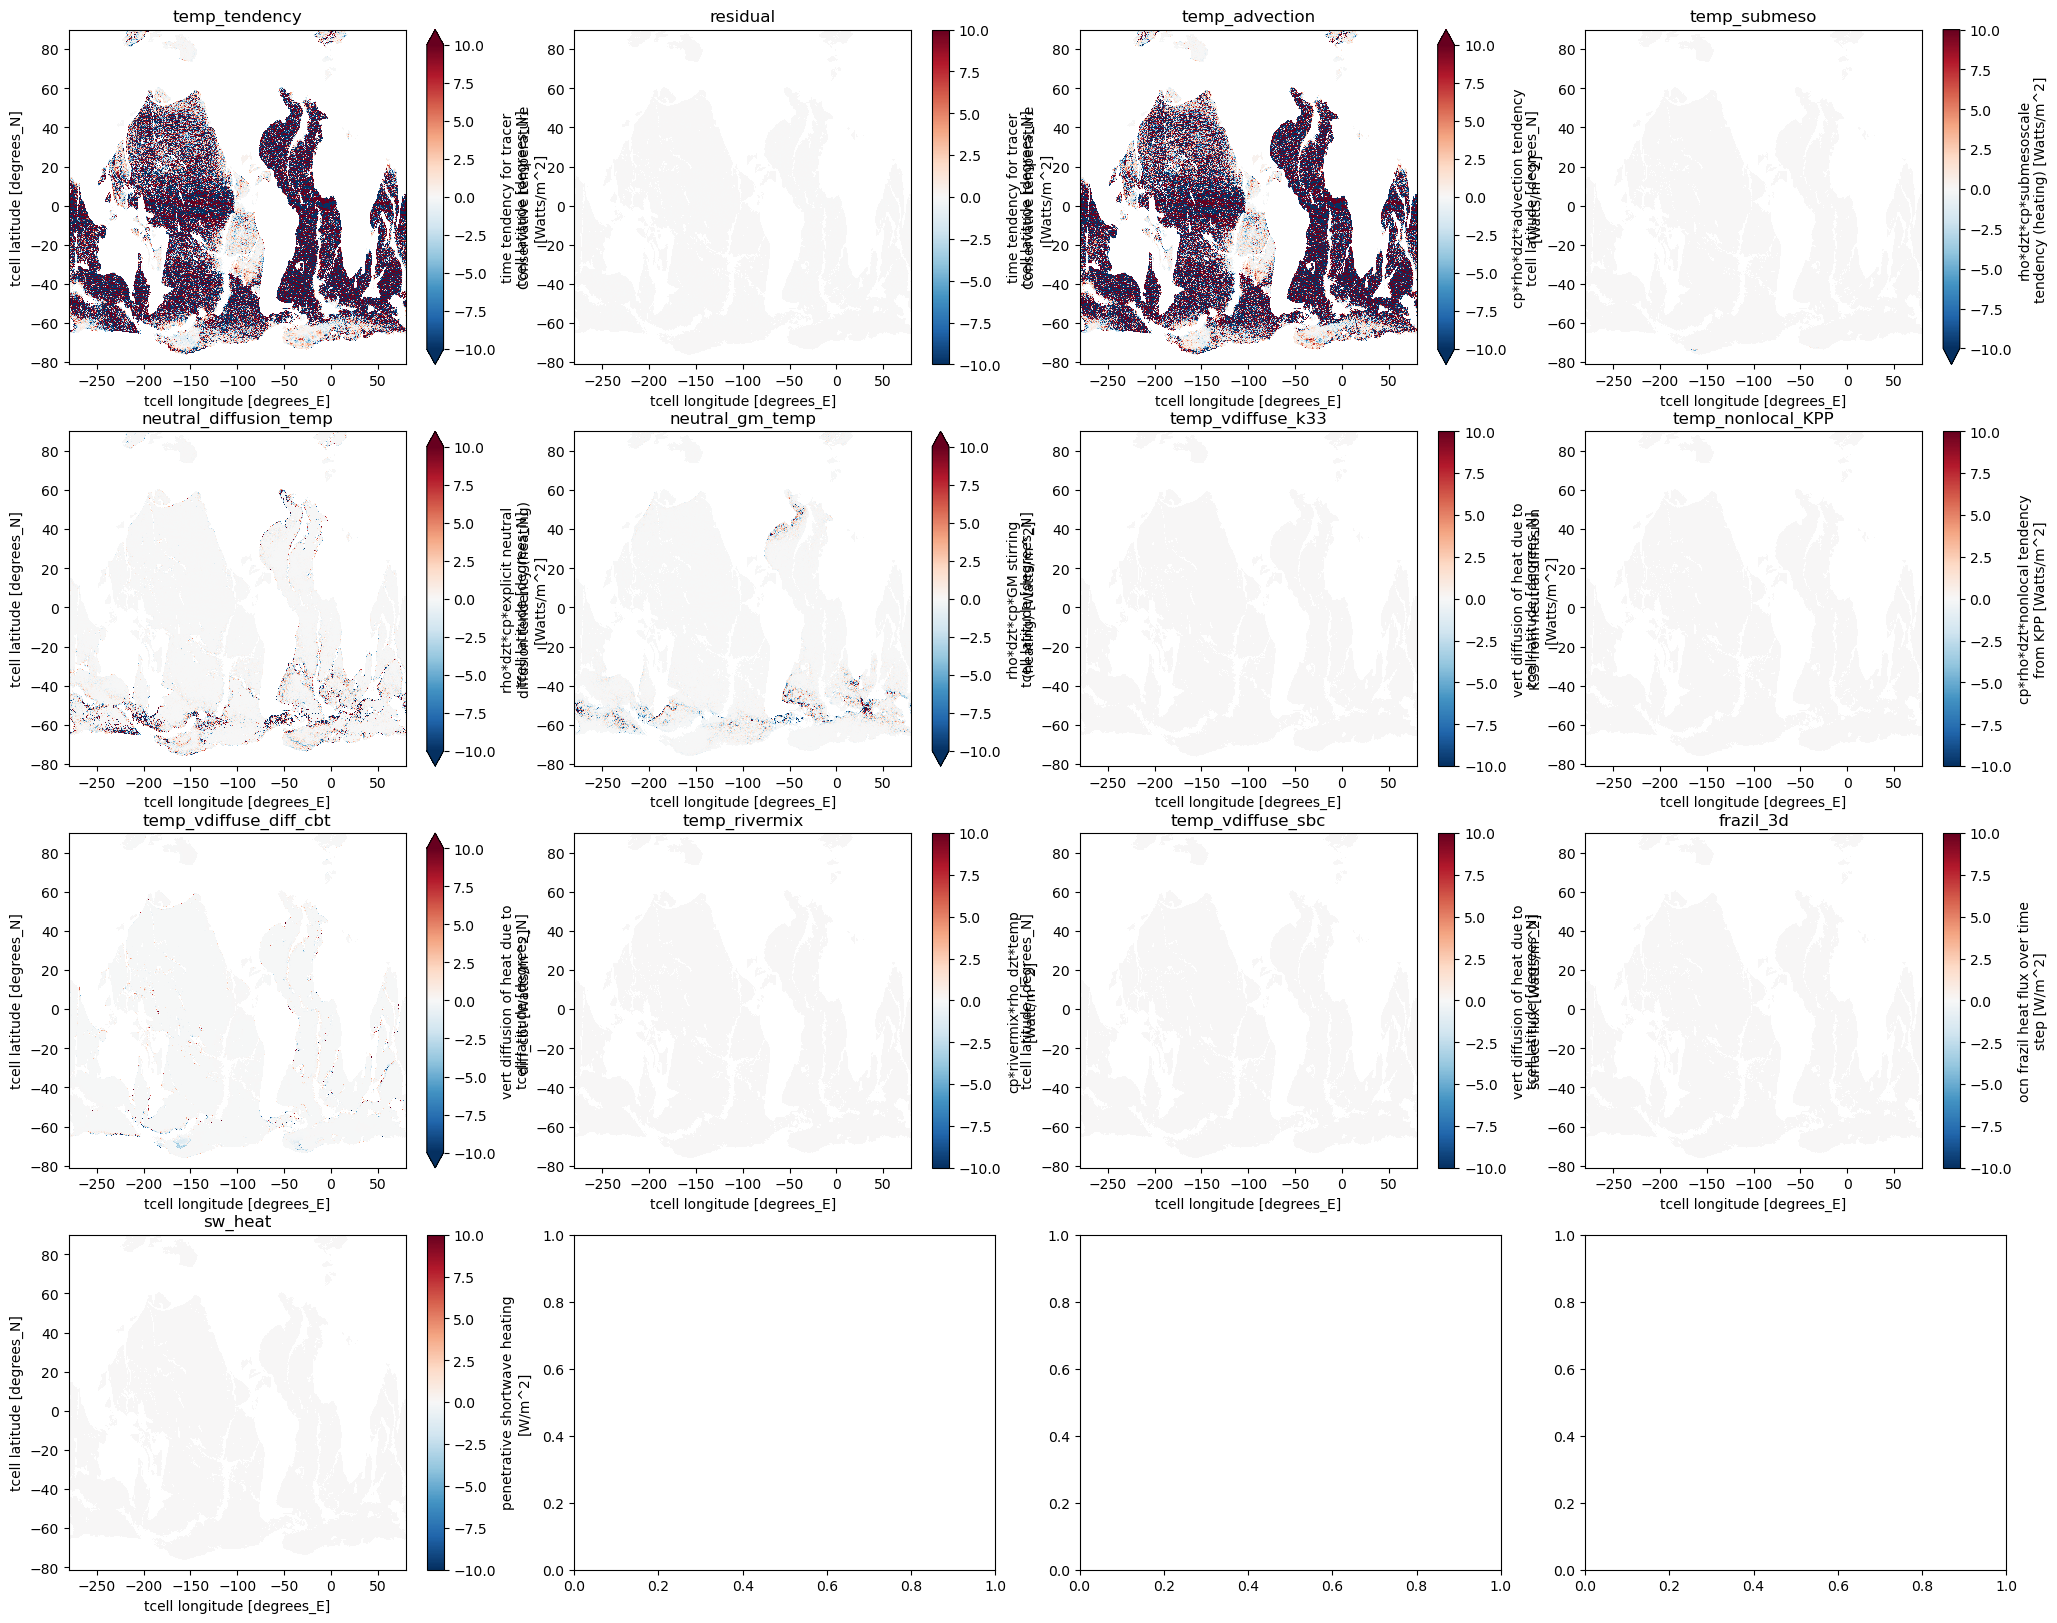

In [8]:
# Plot every term and print out the maximum of the absolute value of every term to confirm closure:
fig, axes = plt.subplots(nrows=4,ncols=4,figsize=(25,20))
axs = axes.reshape(-1)
print('Spatial maximums of terms (Wm-2):')
for i, var in enumerate(bud_vars):
    ds_day_budget_slice[var].plot(ax=axs[i],vmin=-10.,vmax=10.,cmap='RdBu_r')
    axs[i].set_title(var)
    print('%10.5f, ' % (abs(ds_day_budget_slice[var]).max().values) + ' ' + var)


## MLD binned variables:

In [9]:
# Choose time and region:
time = 0; reg_slice = [-300, 300,-90,90]#reg = [-100, 20, 0, 60]

# Load budget:
ds_day_budget_slice = xr.open_dataset(base2 + 'ocean_budget_daily.nc').sel(xt_ocean=slice(reg_slice[0],reg_slice[1]),yt_ocean=slice(reg_slice[2],reg_slice[3])).isel(time=time)

# List the terms:
bud_vars = ['sfc_hflux_pme_in_mld','temp_eta_smooth_in_mld','temp_advection_in_mld','temp_submeso_in_mld','neutral_diffusion_in_mld_temp','neutral_gm_in_mld_temp','temp_vdiffuse_k33_in_mld',
            'temp_nonlocal_KPP_in_mld','temp_vdiffuse_diff_cbt_in_mld',
            'temp_rivermix_in_mld','temp_vdiffuse_sbc_in_mld', 'frazil_3d_in_mld', 
            'sw_heat_in_mld']
# Note: For the online-binned budget the 2D terms (temp_eta_smooth and sfc_hflux_pme) are explicitly binned because the mixed layer depth can be less than the depth of the top grid cell (in which case we don't want to take the whole budget term).

# Compute residual:
ds_day_budget_slice['residual_in_mld'] = ds_day_budget_slice.temp_tendency_in_mld.load().copy(deep=True)
for var in bud_vars:
    ds_day_budget_slice['residual_in_mld'] -= ds_day_budget_slice[var].load()

# Add tendency and residual to budget list:
bud_vars = ['temp_tendency_in_mld','residual_in_mld'] + bud_vars

Spatial maximums of terms (Wm-3):
 128.75252,  temp_tendency_in_mld
   0.09645,  residual_in_mld
  59.04512,  sfc_hflux_pme_in_mld
  25.06187,  temp_eta_smooth_in_mld
 939.78497,  temp_advection_in_mld
  20.86967,  temp_submeso_in_mld
  21.99894,  neutral_diffusion_in_mld_temp
   7.32769,  neutral_gm_in_mld_temp
   0.00016,  temp_vdiffuse_k33_in_mld
 110.51837,  temp_nonlocal_KPP_in_mld
 130.18861,  temp_vdiffuse_diff_cbt_in_mld
 938.21185,  temp_rivermix_in_mld
  89.55099,  temp_vdiffuse_sbc_in_mld
  53.24050,  frazil_3d_in_mld
  33.09821,  sw_heat_in_mld


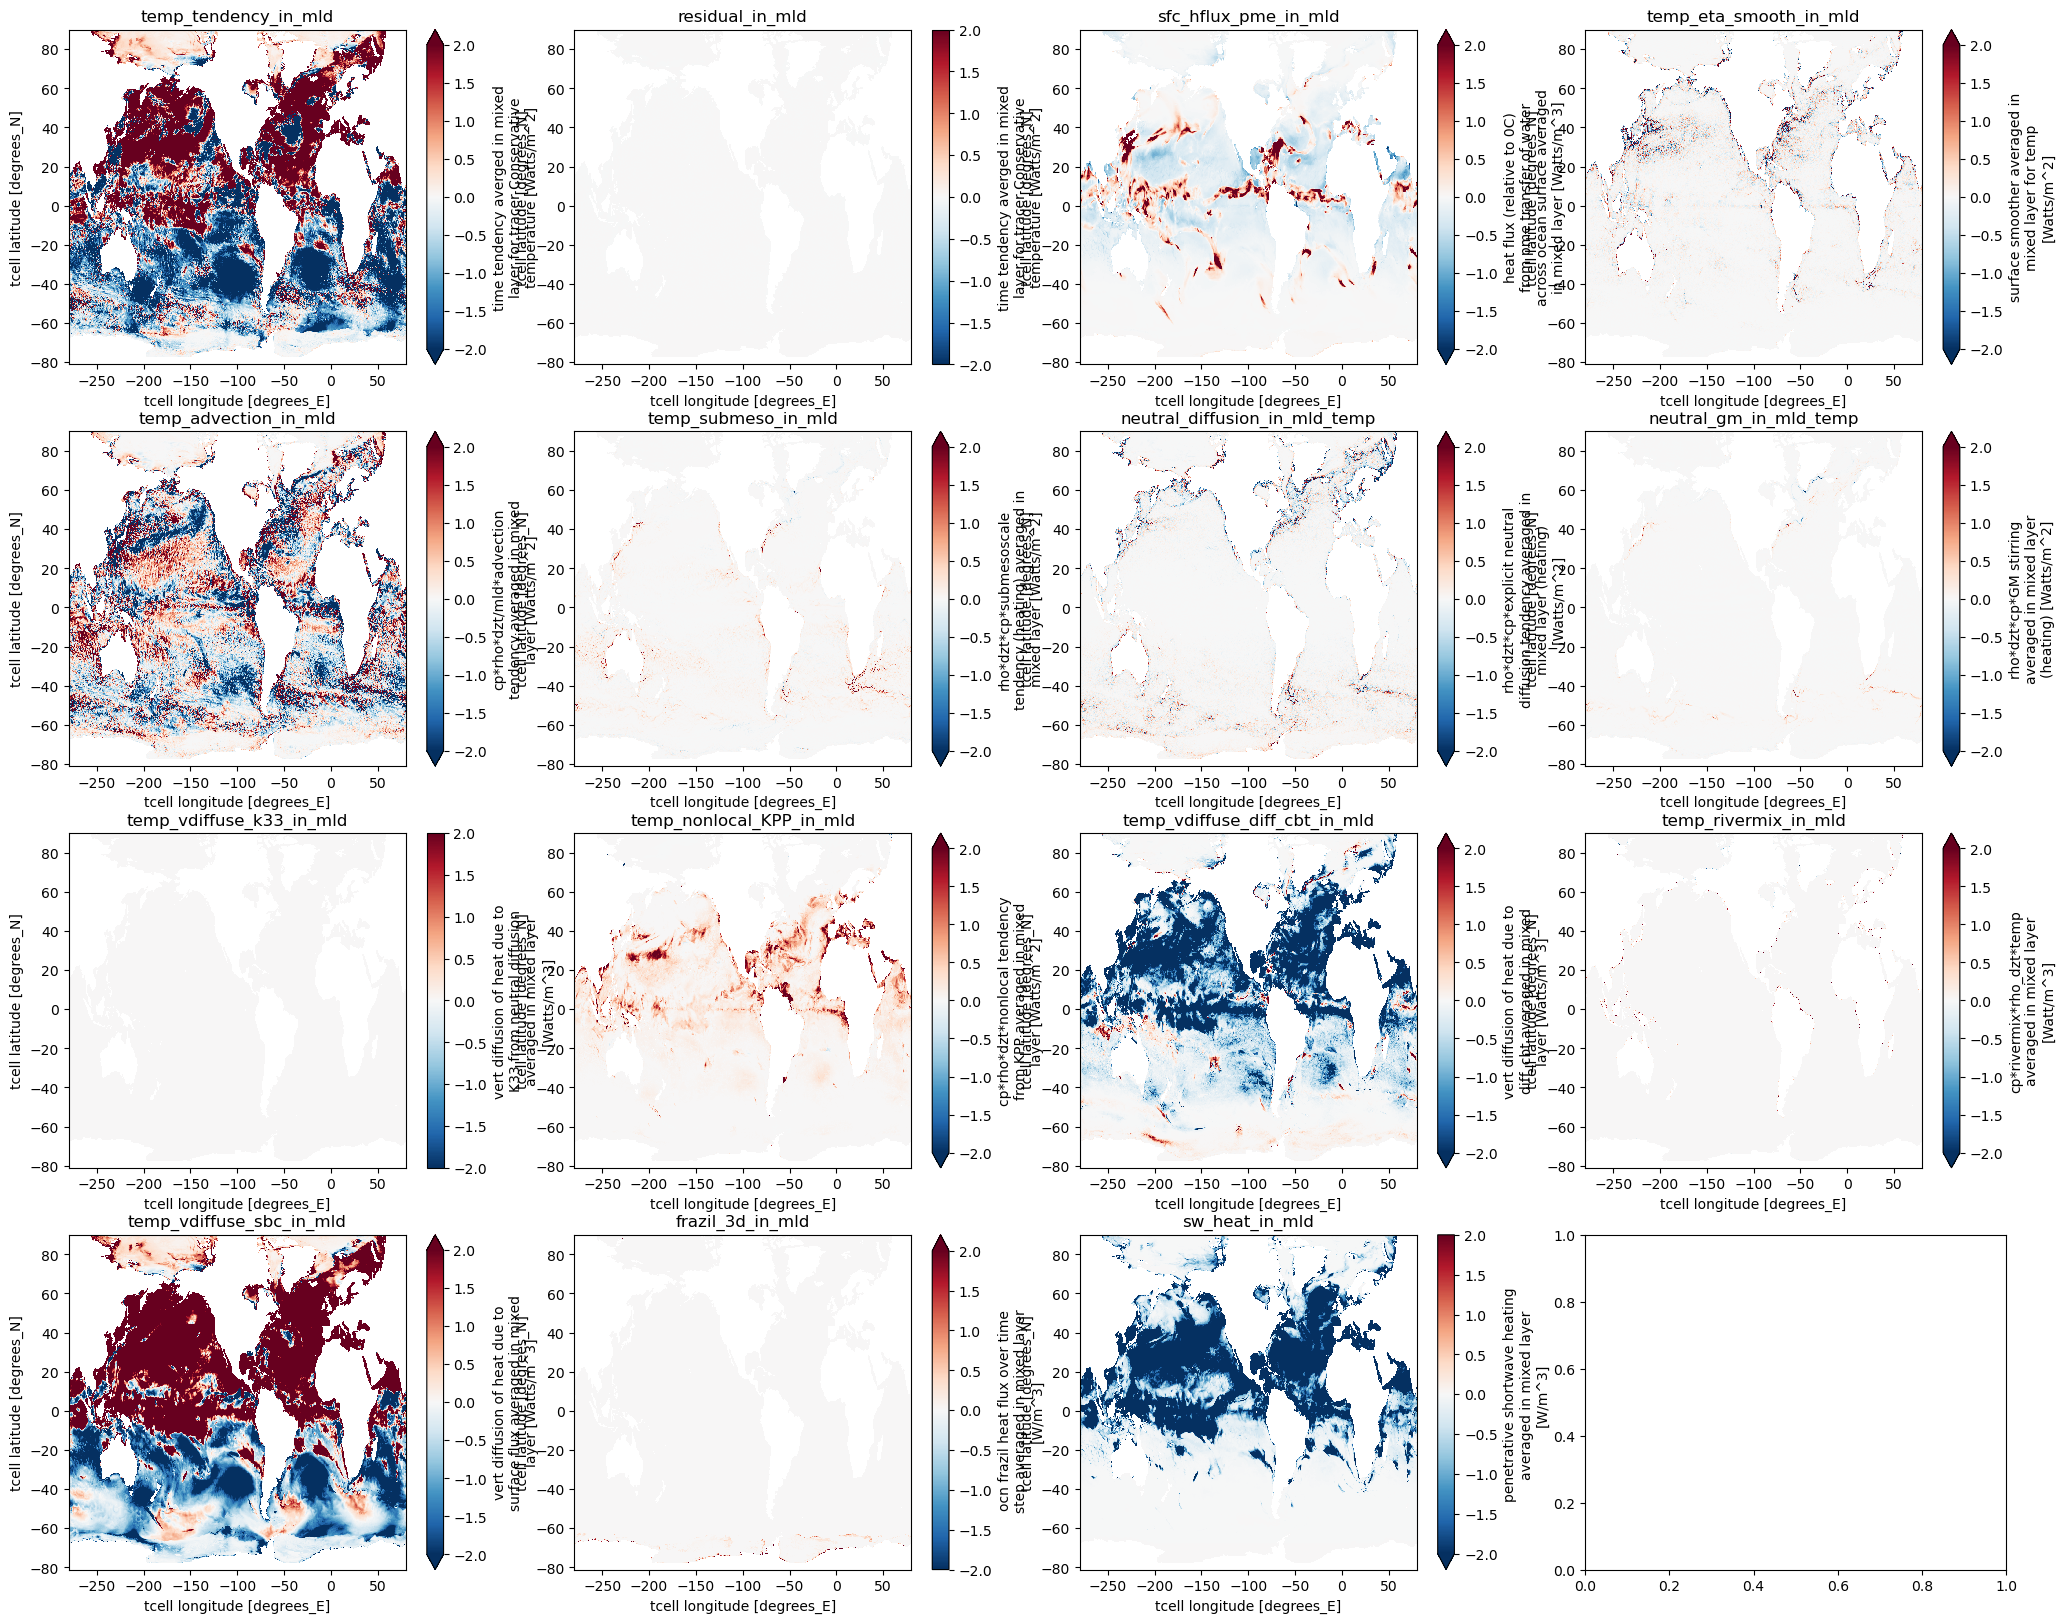

In [11]:
# Plot every term and print out the maximum of the absolute value of every term to confirm closure:
fig, axes = plt.subplots(nrows=4,ncols=4,figsize=(25,20))
axs = axes.reshape(-1)
print('Spatial maximums of terms (Wm-3):')
for i, var in enumerate(bud_vars):
    ds_day_budget_slice[var].plot(ax=axs[i],vmin=-2.,vmax=2.,cmap='RdBu_r')
    axs[i].set_title(var)
    print('%10.5f, ' % (abs(ds_day_budget_slice[var]).max().values) + ' ' + var)


# Define function to compute offline mixed layer temperature budget and tendency/entrainment terms

In [12]:
def compute_mixed_layer_temperature_budget_offline(ds_budget,ds_budget_2d,mld,dzt):
    """
    Compute mixed layer temperature budget

    Inputs:
    ds_budget -> dataset containing time-averaged 3D budget quantities
    ds_budget_2d -> dataset containing time-averaged 2D (surface layer only) budget quantities (these are just added in without summing)
    mld -> dataarray containing time-averaged mixed layer depth
    dzt -> datarray containing time-averaged grid cell thicknesses
    temp_mld_snap -> datarray containing snapshots of temp*rho0*dzt summed over mld
    mld_snap -> dataarray containing snapshots of mld

    Outputs:
    ds_budget_in_mld -> dataset containing all the "internal" (i.e. not including mlt tendency and entrainment) terms in the diagnosed mixed layer temperature budget (2D), in units of degC/second
    """

    # Sum over mixed layer:
    ds_budget_in_mld = ds_budget.isel(st_ocean=0,drop=True).copy(deep=True)
    for ti in tqdm(range(len(ds_budget.time))):
        dzt_ti = dzt.isel(time=ti).load()
        dzt_ti_bot = dzt_ti.cumsum('st_ocean')
        ds_budget_ti = ds_budget.isel(time=ti).load()
        mld_ti = mld.isel(time=ti).load()
        for var in list(ds_budget_in_mld.data_vars):
            ds_budget_in_mld[var][ti,:,:] = ds_budget_ti[var].where(dzt_ti_bot<mld_ti).sum('st_ocean')
            for k in range(len(ds_budget_ti.st_ocean)-1):
                ds_budget_in_mld[var][ti,:,:] += xr.where(np.logical_and(dzt_ti_bot[k,:,:]>mld_ti,dzt_ti_bot[k+1,:,:]<mld_ti),((mld_ti-dzt_ti_bot[k,:,:])/dzt_ti[k,:,:])*ds_budget_ti[var][k,:,:],0.)
            ds_budget_in_mld[var][ti,:,:] = ds_budget_in_mld[var][ti,:,:]/rho0/Cp/mld_ti
            # Units: Wm-2/kg*m3/J*kg*degC/m = degC/sec

    # Add 2D surface layer variables:
    for var in list(ds_budget_2d.data_vars):
        ds_budget_in_mld[var] = (ds_budget_2d[var]/rho0/Cp/mld).load()

    # Compute residual for check:
    ds_budget_in_mld['residual'] = ds_budget_in_mld['temp_tendency'] - ds_budget_in_mld[list(ds_budget_in_mld.data_vars)[1:]].to_array().sum('variable')
        
    return(ds_budget_in_mld)


def compute_mlt_entrainment(ds_budget_in_mld,temp_mld_snap,mld_snap,average_DT):
    """
    Compute mixed layer temperature tendency and entrainment term from snapshots.

    Inputs:
    - ds_budget_in_mld -> MLD-summed budget terms (for temp_tendency and output)
    - temp_mld_snap -> snapshot of temperature * rho0*dzt summed over mixed layer depth
    - mld -> snapshot of MLD

    Outputs:
    - ds_budget_in_mld['mlt_tendency'] and ds_budget_in_mld['entrainment'] in units of degC / second.
    """
    
    # mixed layer temperature tendency from snapshots:
    ds_budget_in_mld['mlt_tendency'] = xr.zeros_like(ds_budget_in_mld['temp_tendency']).copy(deep=True)
    #shape = ds_budget_in_mld.temp_tendency.shape
    ds_budget_in_mld['mlt_tendency'].data = np.transpose((temp_mld_snap/mld_snap).isel(time=slice(1,None)).values - (temp_mld_snap/mld_snap).isel(time=slice(0,-1)).values,(2,0,1))
    ds_budget_in_mld['mlt_tendency'] = ds_budget_in_mld['mlt_tendency']/(average_DT / np.timedelta64(1, 's'))/rho0
    # Units: degC * kg / m3 * m / m / sec / (kg/m3) = degC / sec

    # Entrainment term by residual:
    ds_budget_in_mld['entrainment'] = -(ds_budget_in_mld['temp_tendency'] - ds_budget_in_mld['mlt_tendency'])


# Compute daily and monthly offline binned, as well as online binned, mixed layer temperature budgets

In [13]:
# Offline budget terms grouping:
bud_var_grps = {'temp_advection':['temp_advection','temp_submeso','temp_vdiffuse_k33','neutral_diffusion_temp','neutral_gm_temp'],
                'temp_vert_mixing':['temp_vdiffuse_diff_cbt','temp_nonlocal_KPP'],
                'temp_sbc':['temp_vdiffuse_sbc','frazil_3d','temp_rivermix'],
                'temp_sw_pen':['sw_heat']}
bud_2d_vars = ['temp_eta_smooth','sfc_hflux_pme']

In [14]:
# Add a few terms that are in ds_month in the monthly output:
ds_mon_budget['sw_heat'] = ds_month['sw_heat']
ds_mon_budget['sfc_hflux_pme'] = ds_month['sfc_hflux_pme']
ds_mon_budget['temp_rivermix'] = ds_month['temp_rivermix']

# Group terms:
ds_mon_budget_reduced = ds_mon_budget['temp_tendency'].to_dataset().copy(deep=True)
ds_day_budget_reduced = ds_day_budget['temp_tendency'].to_dataset().copy(deep=True)
for var in bud_var_grps.keys():
    ds_mon_budget_reduced[var] = ds_mon_budget[bud_var_grps[var][0]]
    ds_day_budget_reduced[var] = ds_day_budget[bud_var_grps[var][0]]
    if (len(bud_var_grps[var])>1):
        for raw_var in bud_var_grps[var][1:]:
            ds_mon_budget_reduced[var] += ds_mon_budget[raw_var]
            ds_day_budget_reduced[var] += ds_day_budget[raw_var]

ds_mon_budget_reduced_2d = ds_mon_budget[bud_2d_vars]
ds_day_budget_reduced_2d = ds_day_budget[bud_2d_vars]

In [15]:
# Do monthly computation:
mon_budget_in_mld = compute_mixed_layer_temperature_budget_offline(ds_mon_budget_reduced,ds_mon_budget_reduced_2d,ds_month.mld,ds_month.dht)
# Add 2D vars to sbc term:
for var in bud_2d_vars:
    mon_budget_in_mld['temp_sbc'] += mon_budget_in_mld[var]
    mon_budget_in_mld = mon_budget_in_mld.drop_vars([var])

compute_mlt_entrainment(mon_budget_in_mld,ds_mon_snapshot.temp_mld,ds_mon_snapshot.mld,ds_mon_budget.average_DT)
# Save to file:
mon_budget_in_mld.to_netcdf('/g/data/e14/rmh561/mlt_budget_temporary/mon_budget_temp_om2_omip2_extension_output372.nc')

100%|██████████| 1/1 [00:04<00:00,  4.69s/it]


In [16]:
# Do daily computation:
day_budget_in_mld = compute_mixed_layer_temperature_budget_offline(ds_day_budget_reduced,ds_day_budget_reduced_2d,ds_day.mld,ds_day.dzt)
# Add 2D vars to sbc term:
for var in bud_2d_vars:
    day_budget_in_mld['temp_sbc'] += day_budget_in_mld[var]
    day_budget_in_mld = day_budget_in_mld.drop_vars([var])

compute_mlt_entrainment(day_budget_in_mld,ds_day_snapshot.temp_mld,ds_day_snapshot.mld,ds_day_budget.average_DT)
# Save to file:
day_budget_in_mld.to_netcdf('/g/data/e14/rmh561/mlt_budget_temporary/day_budget_temp_om2_omip2_extension_output372.nc')

100%|██████████| 30/30 [02:08<00:00,  4.30s/it]


In [17]:
# Load from file:
mon_budget_in_mld = xr.open_dataset('/g/data/e14/rmh561/mlt_budget_temporary/mon_budget_temp_om2_omip2_extension_output372.nc').isel(time=0,drop=True)
day_budget_in_mld = xr.open_dataset('/g/data/e14/rmh561/mlt_budget_temporary/day_budget_temp_om2_omip2_extension_output372.nc').mean('time')

In [18]:
# Online budget:
bud_var_grps = {'temp_advection':['temp_advection_in_mld','temp_submeso_in_mld','neutral_diffusion_in_mld_temp','neutral_gm_in_mld_temp','temp_vdiffuse_k33_in_mld'],
                'temp_vert_mixing':['temp_nonlocal_KPP_in_mld','temp_vdiffuse_diff_cbt_in_mld'],
                'temp_sbc':['temp_rivermix_in_mld','temp_vdiffuse_sbc_in_mld', 'frazil_3d_in_mld','sfc_hflux_pme_in_mld','temp_eta_smooth_in_mld'], 
                'temp_sw_pen':['sw_heat_in_mld']}
online_budget_in_mld = (ds_day_budget['temp_tendency_in_mld']/rho0/Cp).rename('temp_tendency').to_dataset()
for var in bud_var_grps.keys():
    online_budget_in_mld[var] = ds_day_budget[bud_var_grps[var][0]]/rho0/Cp
    if (len(bud_var_grps[var])>1):
        for raw_var in bud_var_grps[var][1:]:
            online_budget_in_mld[var] += ds_day_budget[raw_var]/rho0/Cp

# Compute residual for check:
online_budget_in_mld['residual'] = online_budget_in_mld['temp_tendency'].copy(deep=True)
for var in list(online_budget_in_mld.data_vars):
    online_budget_in_mld['residual'] -= online_budget_in_mld[var]

compute_mlt_entrainment(online_budget_in_mld,ds_day_snapshot.temp_mld,ds_day_snapshot.mld,ds_day_budget.average_DT)

In [19]:
online_budget_in_mld = online_budget_in_mld.mean('time')

## Do some plotting

#### Spatial plots comparing monthly, daily offline and online:

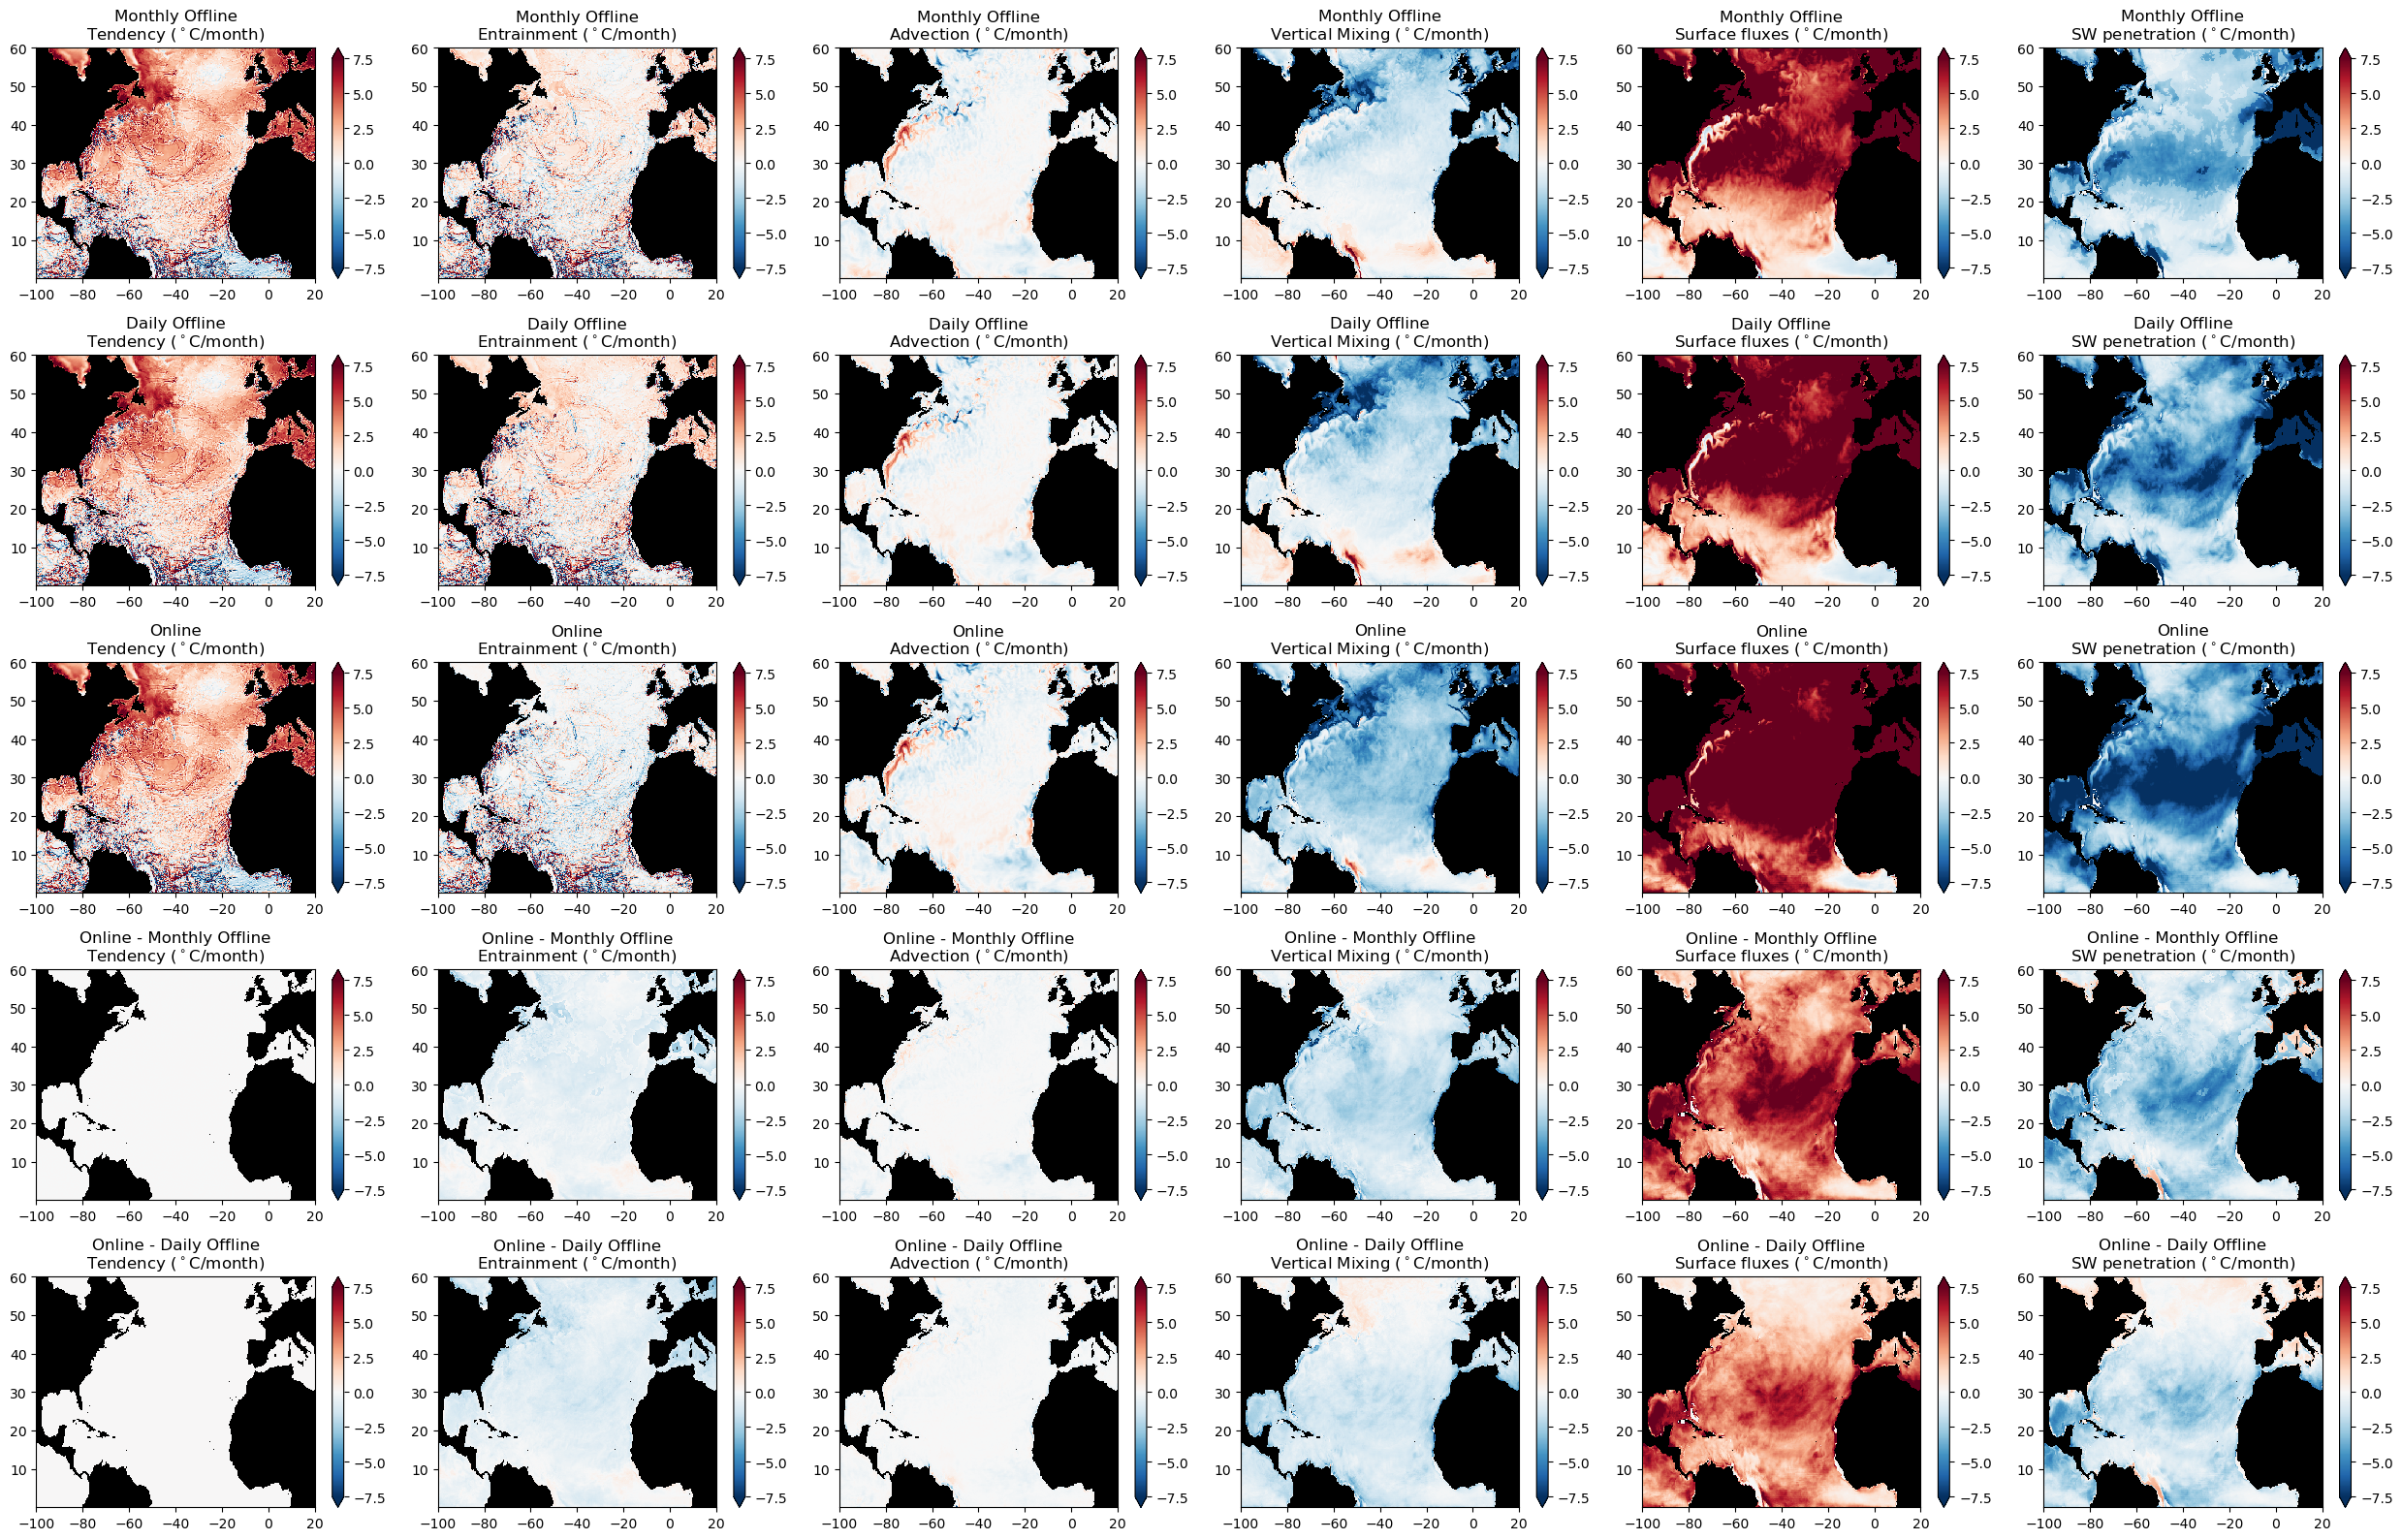

In [20]:
fig, axs = plt.subplots(nrows=5, ncols=6, figsize=(25,16))

vars = ['mlt_tendency','entrainment','temp_advection','temp_vert_mixing','temp_sbc','temp_sw_pen']
labels = ['Tendency','Entrainment','Advection','Vertical Mixing','Surface fluxes','SW penetration']
budgets = [mon_budget_in_mld,day_budget_in_mld,online_budget_in_mld,online_budget_in_mld - mon_budget_in_mld,online_budget_in_mld - day_budget_in_mld]
budget_labels = ['Monthly Offline','Daily Offline','Online','Online - Monthly Offline','Online - Daily Offline']
unit_conv = 86400*30.5
clim = 7.5

for i in range(len(budgets)):
    for j, var in enumerate(vars):
        (budgets[i][var]*unit_conv).plot(ax=axs[i][j],cmap='RdBu_r',vmin=-clim,vmax=clim,extend='both',cbar_kwargs={'label':''}) 
        axs[i][j].set_title(budget_labels[i] + '\n' + labels[j] + ' ($^\circ$C/month)')

for ax in axs.reshape(-1):
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('k')
plt.tight_layout()
plt.savefig('MLT_lin_budget_Atlantic_Jun_2023_Online_Offline_Comparison.png',dpi=250)

#### area averaged plots:

In [ ]:
budget_temp_areaavg = (budgets[1]).sel(xt_ocean=slice(-80.,-20.),yt_ocean=slice(10.,40.)).mean('xt_ocean').mean('yt_ocean')

fig, axes = plt.subplots(nrows=2,ncols=1,figsize=(8,8))

for i, var in enumerate(vars):
    budget_temp_areaavg[var].plot(ax=axes[0])#,label=names[i])
axes[0].legend()
axes[0].grid()
axes[0].set_title('SST tendencies')

#ds_day.mld.sel(xt_ocean=slice(-80.,-20.),yt_ocean=slice(10.,40.)).mean('xt_ocean').mean('yt_ocean').plot(ax=axes[1])
#axes[1].set_title('MLD')
plt.tight_layout()
#plt.savefig('daily_ml_temperature_budget_Atlantic_mainterms_time_series.png',dpi=150)

#### Spatial plots of all terms:

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20,8))
axs = axes.reshape(-1)

# Select budget and convert units
#budget = mon_budget_in_mld*86400*30.5 # Average May-July and convert from degC s-1 to degC/month
#pre_label = 'Monthly Offline '
budget = day_budget_in_mld*86400*30.5 # Average May-July and convert from degC s-1 to degC/month
pre_label = 'Daily Offline '
#budget = online_budget_in_mld.mean('time')*86400*30.5 # Average May-July and convert from degC s-1 to degC/month
#pre_label = 'Online '

vars
clim = 3.
for i, var in enumerate(list(budget.data_vars)):
    budget[var].plot(ax=axs[i],cmap='RdBu_r',vmin=-clim,vmax=clim,extend='both')#,vmax=0.001)#vmin=-0.1,vmax=0.1) 
    axs[i].set_title(pre_label + var)
# Note: Make the color limits much smaller and look at "residual" to see that it closes. Although, of course, you can't 
# check that the mlh_tendency and entrainment calculations close since they are done by residual.

for ax in axs:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('k')
plt.tight_layout()
plt.savefig('daily_mlt_lin_budget_Atlantic_Jun_2023.png',dpi=150)